In [1]:
%load_ext autoreload
%autoreload 2

# Silhouette Score — Intuition by Example

For each point: **how close am I to my team vs the nearest rival team?**

- `a(i)` = avg distance to **my cluster** mates
- `b(i)` = avg distance to **nearest other cluster**
- `silhouette(i) = (b - a) / max(a, b)` → ranges from -1 (wrong team) to +1 (perfect fit)

## Sample data: 3 clusters of users

In [2]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
import matplotlib.pyplot as plt

# 3 clusters: casual, power, reviewer users
rng = np.random.default_rng(42)
data = np.vstack([
    rng.normal(loc=[2, 2], scale=0.8, size=(30, 2)),   # casual
    rng.normal(loc=[7, 7], scale=0.8, size=(30, 2)),   # power
    rng.normal(loc=[7, 2], scale=0.8, size=(30, 2)),   # reviewer
])

df = pd.DataFrame(data, columns=["searches_per_day", "nav_usage_per_day"])
df

,searches_per_day,nav_usage_per_day
0,2.243774,1.168013
1,2.600361,2.752452
2,0.439172,0.958256
3,2.102272,1.747006
4,1.986559,1.317565
...,...,...
85,6.476170,2.356858
86,6.636013,1.019515
87,5.977650,2.138070
88,8.263273,2.127993


## Elbow method: pick K where the curve bends

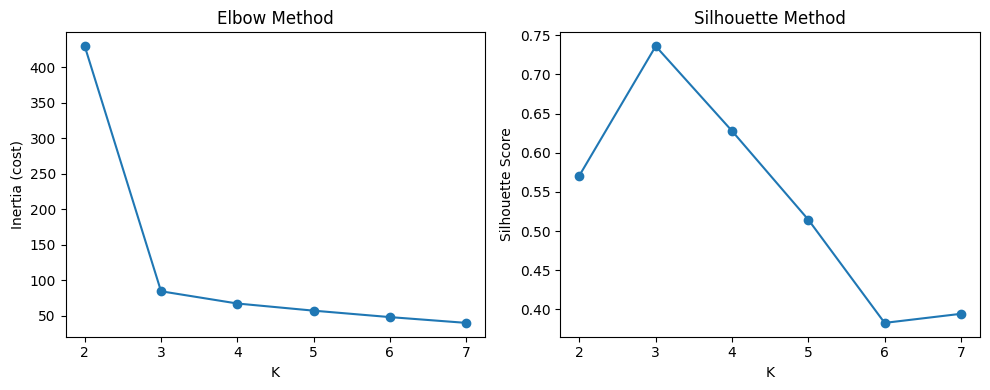

In [3]:
ks = range(2, 8)
inertias = [KMeans(k, random_state=0, n_init=10).fit(df).inertia_ for k in ks]
silhouettes = [
    silhouette_score(df, KMeans(k, random_state=0, n_init=10).fit_predict(df))
    for k in ks
]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(ks, inertias, "o-")
ax1.set(xlabel="K", ylabel="Inertia (cost)", title="Elbow Method")
ax2.plot(ks, silhouettes, "o-")
ax2.set(xlabel="K", ylabel="Silhouette Score", title="Silhouette Method")
plt.tight_layout()

## Per-point silhouette: who's on the right team?

In [4]:
labels = KMeans(3, random_state=0, n_init=10).fit_predict(df)

(
    df
    .assign(
        cluster=labels,
        silhouette=silhouette_samples(df, labels),
    )
    .sort_values(["cluster", "silhouette"], ascending=[True, False])
)

,searches_per_day,nav_usage_per_day,cluster,silhouette
22,2.093349,2.174951,0,0.832142
3,2.102272,1.747006,0,0.828225
12,1.657338,1.718293,0,0.822566
14,2.330186,2.344657,0,0.817584
10,1.852110,1.455256,0,0.814447
...,...,...,...,...
35,5.979451,6.093370,2,0.689138
59,8.281423,6.808515,2,0.686752
56,6.524680,5.843154,2,0.671763
47,5.650132,5.842310,2,0.593351


## Visual: color = cluster, size = silhouette score

Big dots = confident assignment. Small dots = borderline (near 0 or negative).

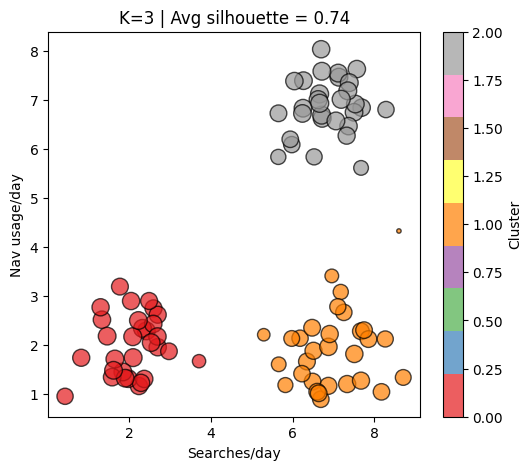

In [5]:
sil = silhouette_samples(df, labels)

fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(
    df["searches_per_day"], df["nav_usage_per_day"],
    c=labels, cmap="Set1", s=sil.clip(0.05) * 200, alpha=0.7, edgecolors="k",
)
ax.set(xlabel="Searches/day", ylabel="Nav usage/day", title=f"K=3 | Avg silhouette = {sil.mean():.2f}")
plt.colorbar(scatter, label="Cluster")